In [ ]:
from EarthquakeSignal import config, EarthquakeBatchProcessor
from LadrunoGraphStyle import set_default_plot_params
set_default_plot_params()

In [ ]:
# pip list

### Set config manual 

In [ ]:
config = {
    'file_extension': '.txt',
    'unit_factor': 1,
    
    'apply_baseline_correction': True,
    'apply_arias_analysis': True,
    'apply_fourier_analysis': True,
    '_compute_newmark_spectra': True,
    'compute_rotd': True,
    'print_summary': True,
    
    'plot_signals': True,
    'plot_corrected_signals': True,
    'plot_arias_signals': True,
    'plot_fourier_signals': True,  
    'plot_newmark_spectra': True,
    'plot_rotd': True,
    
    'writer': True, 
}


In [ ]:
registers_path = r'data/Selected'


In [ ]:
processor = EarthquakeBatchProcessor(registers_path, config ,  n_jobs=4) 
earthquake = processor.process_all()


### For each earthquake

In [ ]:
earthquake['APED'].print_summary()
earthquake['APED'].plot_original_signals()
earthquake['APED'].plot_corrected_signals()
earthquake['APED'].plot_arias_signals()
earthquake['APED'].plot_fourier_signals()
earthquake['APED'].plot_newmark_spectra()


In [31]:
record = earthquake['APED']


print("🔹 Arias Intensity")
print(f"Significant Duration Start  : {record.arias['H1']['t_start']:.3f} s")
print(f"Significant Duration End    : {record.arias['H1']['t_end']:.3f} s")
print(f"Total Arias Intensity       : {record.arias['H1']['IA_total']:.5f} m/s")
print(f"Destructive Potential Index : {record.arias['H1']['pot_dest']:.5f}")


print("\n🔹 Fourier Analysis")
print("Dominant Periods (s):", record.fourier['H1']['dominant_periods'])

🔹 Arias Intensity
Significant Duration Start  : 4.870 s
Significant Duration End    : 34.830 s
Total Arias Intensity       : 19.03169 m/s
Destructive Potential Index : 0.48883

🔹 Fourier Analysis
Dominant Periods (s): [0.48888268 0.2551312  0.86216749 0.15640751]


## Keys and Methods

In [22]:

first_key = next(iter(earthquake))
eq = earthquake[first_key]

print("Keys:")
for key in vars(eq):
    print(f"  - {key}")

print("\nMethods:")
import inspect
methods = [name for name, obj in inspect.getmembers(eq, inspect.ismethod) if not name.startswith('_')]
for m in methods:
    print(f"  - {m}()")

Keys:
  - filepath
  - config
  - name
  - dt
  - signals
  - component_names
  - corrected_acc
  - corrected_vel
  - corrected_disp
  - arias
  - newmark_spectra
  - rotd
  - fourier
  - summary_tool
  - plotter_tool
  - comparison_tool
  - arias_plotter
  - fourier_plotter
  - newmark_plotter
  - rotd_plotter
  - exporter
  - signals_raw

Methods:
  - export()
  - load_and_process()
  - plot_arias_signals()
  - plot_corrected_signals()
  - plot_fourier_signals()
  - plot_newmark_spectra()
  - plot_original_signals()
  - plot_rotd()
  - print_summary()


In [44]:
print("PGA Comparison (direct vs spectral) for each record and component:")
print(f"{'Record':<20} {'Comp':<4} {'PGA':>12}" )

for name, eq in earthquake.items():
    print("--"*10)
    for comp in ['H1', 'H2', 'V']:
        psa_array = eq.newmark_spectra[comp]['PSa']
        pga = psa_array[0]

        print(f"{name:<20} {comp:<4} {pga:12.4f}")
              

PGA Comparison (direct vs spectral) for each record and component:
Record               Comp          PGA
--------------------
AMNT                 H1         0.5481
AMNT                 H2         0.4108
AMNT                 V          0.1756
--------------------
APED                 H1         0.8464
APED                 H2         1.4579
APED                 V          0.7507
--------------------
Concepcion           H1         0.2913
Concepcion           H2         0.4183
Concepcion           V          0.4006
--------------------
Constitucion         H1         0.5646
Constitucion         H2         0.6608
Constitucion         V          0.3628
--------------------
Llolleo              H1         0.3332
Llolleo              H2         0.5742
Llolleo              V          0.7434
--------------------
RSN160               H1         0.6102
RSN160               H2         0.7791
RSN160               V          0.6387
--------------------
RSN4116              H1         0.6049
RSN411

### All spectra

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Calcular ruta correcta ---
project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
output_dir = os.path.join(project_root, 'outputs')
os.makedirs(output_dir, exist_ok=True)
svg_path = os.path.join(output_dir, "all _selected_records.svg")

# --- Graficar espectros ---
plt.figure(figsize=(14, 4))

# Subplot para H1
plt.subplot(1, 2, 1)
for rsn, eq in earthquake.items():
    try:
        T_H1 = eq.newmark_spectra['H1']['T']
        PSa_H1 = eq.newmark_spectra['H1']['PSa']
        plt.plot(T_H1, PSa_H1, linewidth=1.5, label=f"{rsn}")
    except KeyError:
        print(f"Warning: {rsn} missing H1 spectrum")

plt.title("Component H1" ,fontweight='bold')
plt.xlabel("Period [s]",  fontweight='bold')
plt.ylabel("PSa [g]",  fontweight='bold')
plt.grid(True, which='both')
plt.xlim(left=0, right=5)
plt.tick_params(axis='both', labelsize=8)
plt.legend( loc='upper right', ncol=2)

# Subplot para H2
plt.subplot(1, 2, 2)
for rsn, eq in earthquake.items():
    try:
        T_H2 = eq.newmark_spectra['H2']['T']
        PSa_H2 = eq.newmark_spectra['H2']['PSa']
        plt.plot(T_H2, PSa_H2, linewidth=1.5, label=f"{rsn}")
    except KeyError:
        print(f"Warning: {rsn} missing H2 spectrum")

plt.title("Component H2",  fontweight='bold')
plt.xlabel("Period [s]",  fontweight='bold')
plt.ylabel("PSa [g]",  fontweight='bold')
plt.grid(True, which='both')
plt.xlim(left=0, right=5)
plt.tick_params(axis='both', labelsize=8)
plt.legend( loc='upper right', ncol=2)

plt.suptitle("All Records", fontsize=11, fontweight='bold')

# --- Guardar como SVG en outputs/
svg_path=r'C:\Users\ppala\OneDrive\01. Brain\10. Ph.D U ANDES\07. Publicaciones\01. AmplificacionMuros\02. Modelos Shell\04. Model10stories\SelectedSeismic'

# Guardar en Figures/01.pdf
plt.savefig(os.path.join(svg_path, 'seismic_selected.pdf'),format='pdf',bbox_inches='tight')
plt.savefig(os.path.join(svg_path, 'seismic_selected.svg'),format='svg',bbox_inches='tight')


plt.show()




### Rotd100

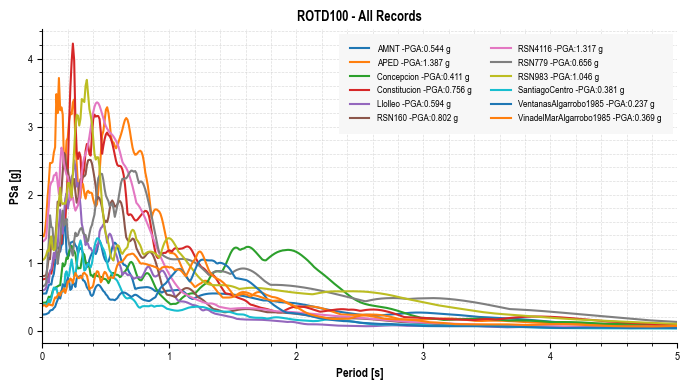

In [36]:


# Create figure with 1 row and 1 column
plt.figure(figsize=(7, 4))

# Subplot for ROTD100
plt.subplot(1, 1, 1)
for rsn, eq in earthquake.items():
    try:

        T = eq.rotd['T']
        PSa_rotd100 = eq.rotd['ROTD100']
        pga = round(PSa_rotd100[0], 3)
        plt.plot(T, PSa_rotd100, linewidth=1.5, label=f"{rsn} -PGA:{pga} g")
    except KeyError:
        print(f"Warning: {rsn} missing ROTD100 spectrum")

plt.title("ROTD100 - All Records", fontsize=10, fontweight='bold')
plt.xlabel("Period [s]", fontsize=9, fontweight='bold')
plt.ylabel("PSa [g]", fontsize=9, fontweight='bold')
plt.grid(True, which='both')
plt.xlim(left=0, right=5)
plt.tick_params(axis='both', labelsize=8)
plt.legend(fontsize=7, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()


In [ ]:


# Create figure with 1 row and 1 column
plt.figure(figsize=(7, 4))

# Subplot for ROTD50
plt.subplot(1, 1, 1)
for rsn, eq in earthquake.items():
    try:

        T = eq.rotd['T']
        PSa_rotd50 = eq.rotd['ROTD50']
        pga = round(PSa_rotd50[0], 3)
        plt.plot(T, PSa_rotd50, linewidth=1.5, label=f"{rsn} -PGA:{pga} g")
    except KeyError:
        print(f"Warning: {rsn} missing ROTD50 spectrum")

plt.title("ROTD50 - All Records", fontsize=10, fontweight='bold')
plt.xlabel("Period [s]", fontsize=9, fontweight='bold')
plt.ylabel("PSa [g]", fontsize=9, fontweight='bold')
plt.grid(True, which='both')
plt.xlim(left=0, right=5)
plt.tick_params(axis='both', labelsize=8)
plt.legend(fontsize=7, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()
